In [1]:
from time import perf_counter
import numpy as np
import scipy as sp
import pandas as pd
from matplotlib import pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VARMAX
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product

## Reading in the Datasets

In [2]:
# Global Temperature
def get_year(year: int):
    """
    Converts a year to an index offset from 1750.

    Args:
        year (int): A year between 1750 and 2015 inclusive.

    Returns:
        int: The index of the year (e.g. 1750 → 0, 1751 → 1).
    """
    return year - 1750

gt_data_filtered = np.load("datasets/gt_data_filtered.npy")


# # eg: gt_data_filtered[0, :, get_year(2015)]

# # [ (0, 1) # {0: land temperatures, 1: ocean temperatures}
# #   (0-11) # month of the year
# #   (0-266) # year 1750 - 2015
# #  ]

gt_data_noNaNs = gt_data_filtered[:, :, 100]

def get_year_noNaNs(year: int):
    """
    Converts a year to an index offset from 1850.

    Note: This is for the noNaNs data since the first 100 years have NaNs

    Args:
        year (int): A year between 1850 and 2015 inclusive.

    Returns:
        int: The index of the year (e.g. 1850 → 0, 1851 → 1).
    """
    return year - 1850

gt_data_land_temps = gt_data_filtered[0, :, 3:]

# # eg: gt_data_land_temps[:, get_year_land(1800)] # returns the land average temperatures for every month in the year 1800

# # [ (0-11) # month of the year
# #   (0-263) # year 1753 - 2015
# #  ]

def get_year_land(year: int):
    """
    Converts a year to an index offset from 1753.

    Note: This is for the land temps data since the first 3 years had NaNs for land

    Args:
        year (int): A year between 1753 and 2015 inclusive.

    Returns:
        int: The index of the year (e.g. 1753 → 0, 1754 → 1).
    """
    return year - 1753

In [3]:
# Average Temperature
avtemp_df = pd.read_csv("datasets/Average_Temperature_1900_2023.csv", index_col=0)
avtemp_df = avtemp_df.astype(float)  # Setting the temperature datatypes to floats
avtemp_df["temp"] = avtemp_df["Average_Fahrenheit_Temperature"]
avtemp_df = avtemp_df.drop(columns=["Average_Fahrenheit_Temperature"])  # Renaming the column

In [4]:
co2_ghg_df = pd.read_csv("datasets/CO2 Emissions Data.csv")
world_data = co2_ghg_df[co2_ghg_df['country'] == "World"]

# co2 emissions in the entire world (in millions of tonnes)
co2_world_df = world_data[["year", "co2"]]
# ghg emissions in the entire world (in millions of tonnes)
ghg_world_df = world_data[["year", "total_ghg"]]

co2_world_df.index = co2_world_df["year"]
co2_world_df.drop(columns=["year"], inplace=True)

co2_world_df.index = pd.RangeIndex(1750, 2025)

In [5]:
# Sea Ice Levels
seaice_df = pd.read_csv("datasets/seaice.csv")
seaice_df.columns = seaice_df.columns.str.strip()  # Stripping whitespace from column names
seaice_df["date"] = pd.to_datetime(seaice_df[["Year", "Month", "Day"]])  # Making a "date" column
seaice_df = seaice_df.drop(columns=["Month", "Day", "Source Data"])
seaice_df = seaice_df.set_index("date")  # Setting the date as the index

# Computing the averages for each year
seaice_north_yearly_df = seaice_df[seaice_df["hemisphere"] == "north"].groupby("Year")["Extent"].agg(["mean", "std"])  # Computing the mean and std
seaice_north_yearly_df = seaice_north_yearly_df.drop(index=[1978, 2019])  # Don't have data for the whole of each year; changes std value

seaice_south_yearly_df = seaice_df[seaice_df["hemisphere"] == "south"].groupby("Year")["Extent"].agg(["mean", "std"])
seaice_south_yearly_df = seaice_south_yearly_df.drop(index=[1978, 2019])

# Computing daily global seaice levels
seaice_global_yearly_df = seaice_north_yearly_df + seaice_south_yearly_df

seaice_global_df = seaice_df[seaice_df["hemisphere"] == "north"]["Extent"] + seaice_df[seaice_df["hemisphere"] == "south"]["Extent"]

## Fitting Models

### Average Temperature

In [6]:
# Fitting an ARMA model to the average temperature dataset
z = avtemp_df.values.copy()  # The dataset
n = 30  # The number of predictions to make into the future

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    warnings.simplefilter("ignore", UserWarning)
    # Determining optimal hyperparameters
    p_max, q_max, d_max = 10, 10, 1
    opt_p, opt_q, opt_d = None, None, None
    best_aic = float("inf")
    for p in range(1, p_max + 1):
        for q in range(1, q_max + 1):
            for d in range(0, d_max + 1):
                # model = ARIMA(z, order=(p, d, q)).fit(method='innovations_mle')
                model = ARIMA(z, order=(p, d, q)).fit(method='statespace')
                if model.aic < best_aic:
                    best_aic = model.aic
                    opt_p = p
                    opt_q = q
                    opt_d = d

# Determining the optimal AIC
print(f"Best AIC: {best_aic}")

Best AIC: 419.8138020783227


/Users/ethanpalenske/Desktop/Winter 2026 Classes/.acme/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


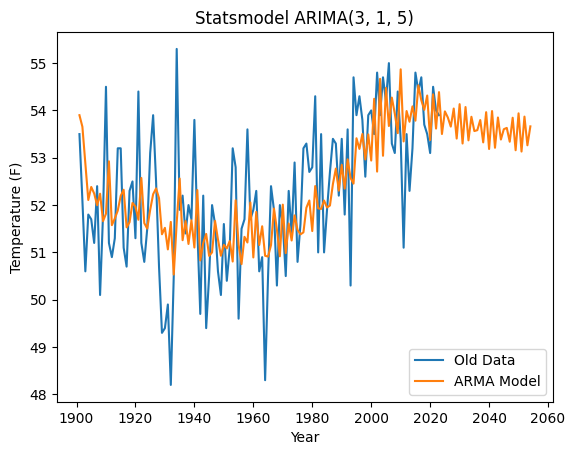

In [7]:
# Intialize the ARIMA model with optimal parameters
model = ARIMA(z, order=(opt_p, opt_d, opt_q)).fit(method='statespace')

# Predict from the beginning of the model to 30 observations in the future
pred = model.predict(start=0, end=len(z)+n)
plt.plot(np.arange(1900 + 1, 1900+len(z)), z[1:], label="Old Data")
plt.plot(np.arange(1900 + 1, 1900+len(pred)), pred[1:], label="ARMA Model")
plt.xlabel("Year")
plt.ylabel("Temperature (F)")
plt.title(f"Statsmodel ARIMA({opt_p}, {opt_d}, {opt_q})")
plt.legend()
plt.show()

Best AIC: 426.4711792937421
AR Parameters: [0.97675859]
MA Parameters: [-0.8397341]


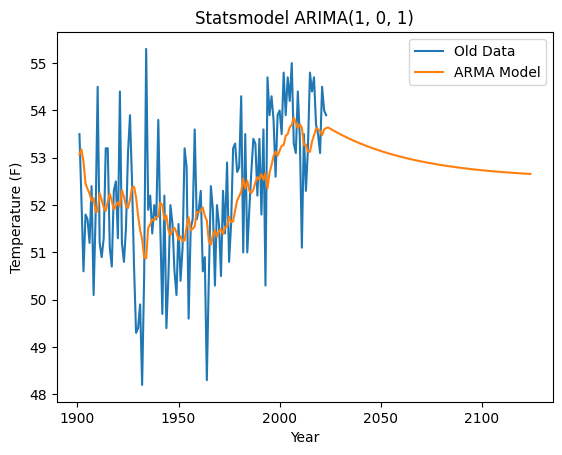

In [8]:
# Determining the parameters of the optimal ARMA(p, d, q) model
# Intialize the ARIMA model
p, d, q = 1, 0, 1
model = ARIMA(z, order=(p, d, q)).fit(method='innovations_mle')

# Determining the optimal AIC
print(f"Best AIC: {model.aic}")

# Determining the parameters
print(f"AR Parameters: {model.arparams}")
print(f"MA Parameters: {model.maparams}")

# Predict from the beginning of the model to n observations in the future
n = 100
pred = model.predict(start=0, end=len(z) + n)
plt.plot(np.arange(1900 + 1, 1900 + len(z)), z[1:], label="Old Data")
plt.plot(np.arange(1900 + 1, 1900 + len(pred)), pred[1:], label="ARMA Model")
plt.xlabel("Year")
plt.ylabel("Temperature (F)")
plt.title(f"Statsmodel ARIMA({p}, {d}, {q})")
plt.legend()
plt.show()

### Seaice Dataset

Best AIC: 12.188386371896115


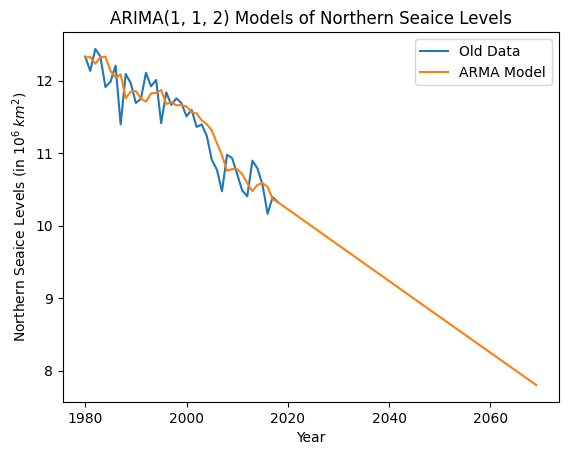

In [9]:
# Fitting an ARMA model to the Northern Seaice dataset
z = seaice_north_yearly_df["mean"].values.copy()  # The dataset
n = 50  # The number of predictions to make into the future

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    warnings.simplefilter("ignore", UserWarning)
    # Determining optimal hyperparameters
    p_max, q_max, d_max = 5, 5, 3
    opt_p, opt_q, opt_d = None, None, None
    best_aic = float("inf")
    for p in range(1, p_max + 1):
        for q in range(1, q_max + 1):
            for d in range(0, d_max + 1):
                # model = ARIMA(z, order=(p, d, q)).fit(method='innovations_mle')
                model = ARIMA(z, order=(p, d, q)).fit(method='statespace')
                if model.aic < best_aic:
                    best_aic = model.aic
                    opt_p = p
                    opt_q = q
                    opt_d = d

# Determining the optimal AIC
print(f"Best AIC: {best_aic}")

# Intialize the ARIMA model with optimal parameters
model = ARIMA(z, order=(opt_p, opt_d, opt_q)).fit(method='statespace')

# Predict from the beginning of the model to n observations in the future
pred = model.predict(start=0, end=len(z)+n)
plt.plot(np.arange(1979 + 1, 1979 + len(z)), z[1:], label="Old Data")
plt.plot(np.arange(1979 + 1, 1979 + len(pred)), pred[1:], label="ARMA Model")
plt.xlabel("Year")
plt.ylabel(r"Northern Seaice Levels (in $10^6 \; km^2$)")
plt.title(f"ARIMA({opt_p}, {opt_d}, {opt_q}) Models of Northern Seaice Levels")
plt.legend()
plt.show()

Best AIC: 52.03112895122358


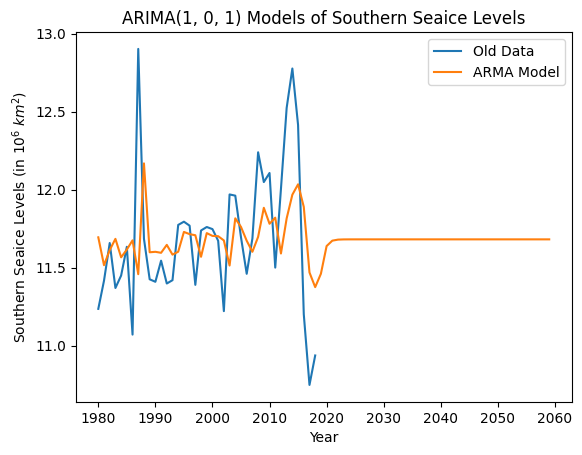

In [10]:
# Fitting an ARMA model to the Southern Seaice dataset
z = seaice_south_yearly_df["mean"].values.copy()  # The dataset
n = 40  # The number of predictions to make into the future

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    warnings.simplefilter("ignore", UserWarning)
    # Determining optimal hyperparameters
    p_max, q_max, d_max = 5, 5, 3
    opt_p, opt_q, opt_d = None, None, None
    best_aic = float("inf")
    for p in range(1, p_max + 1):
        for q in range(1, q_max + 1):
            for d in range(0, d_max + 1):
                # model = ARIMA(z, order=(p, d, q)).fit(method='innovations_mle')
                model = ARIMA(z, order=(p, d, q)).fit(method='statespace')
                if model.aic < best_aic:
                    best_aic = model.aic
                    opt_p = p
                    opt_q = q
                    opt_d = d

# Determining the optimal AIC
print(f"Best AIC: {best_aic}")

# Intialize the ARIMA model with optimal parameters
model = ARIMA(z, order=(opt_p, opt_d, opt_q)).fit(method='statespace')

# Predict from the beginning of the model to n observations in the future
pred = model.predict(start=0, end=len(z)+n)
plt.plot(np.arange(1979 + 1, 1979 + len(z)), z[1:], label="Old Data")
plt.plot(np.arange(1979 + 1, 1979 + len(pred)), pred[1:], label="ARMA Model")
plt.xlabel("Year")
plt.ylabel(r"Southern Seaice Levels (in $10^6 \; km^2$)")
plt.title(f"ARIMA({opt_p}, {opt_d}, {opt_q}) Models of Southern Seaice Levels")
plt.legend()
plt.show()

Best AIC: 49.51562722343767


/Users/ethanpalenske/Desktop/Winter 2026 Classes/.acme/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


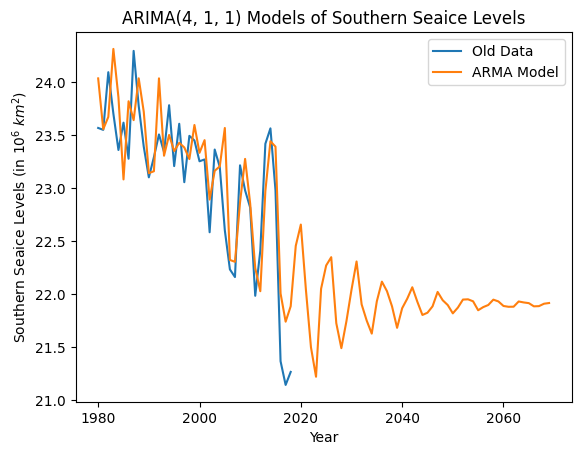

In [11]:
# Fitting an ARMA model to the Southern Seaice dataset
z = seaice_global_yearly_df["mean"].values.copy()  # The dataset
n = 50  # The number of predictions to make into the future

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    warnings.simplefilter("ignore", UserWarning)
    # Determining optimal hyperparameters
    p_max, q_max, d_max = 5, 5, 3
    opt_p, opt_q, opt_d = None, None, None
    best_aic = float("inf")
    for p in range(1, p_max + 1):
        for q in range(1, q_max + 1):
            for d in range(0, d_max + 1):
                # model = ARIMA(z, order=(p, d, q)).fit(method='innovations_mle')
                model = ARIMA(z, order=(p, d, q)).fit(method='statespace')
                if model.aic < best_aic:
                    best_aic = model.aic
                    opt_p = p
                    opt_q = q
                    opt_d = d

# Determining the optimal AIC
print(f"Best AIC: {best_aic}")

# Intialize the ARIMA model with optimal parameters
model = ARIMA(z, order=(opt_p, opt_d, opt_q)).fit(method='statespace')

# Predict from the beginning of the model to n observations in the future
pred = model.predict(start=0, end=len(z)+n)
plt.plot(np.arange(1979 + 1, 1979 + len(z)), z[1:], label="Old Data")
plt.plot(np.arange(1979 + 1, 1979 + len(pred)), pred[1:], label="ARMA Model")
plt.xlabel("Year")
plt.ylabel(r"Southern Seaice Levels (in $10^6 \; km^2$)")
plt.title(f"ARIMA({opt_p}, {opt_d}, {opt_q}) Models of Southern Seaice Levels")
plt.legend()
plt.show()

Best AIC: 49.51562722343767


/Users/ethanpalenske/Desktop/Winter 2026 Classes/.acme/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/ethanpalenske/Desktop/Winter 2026 Classes/.acme/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


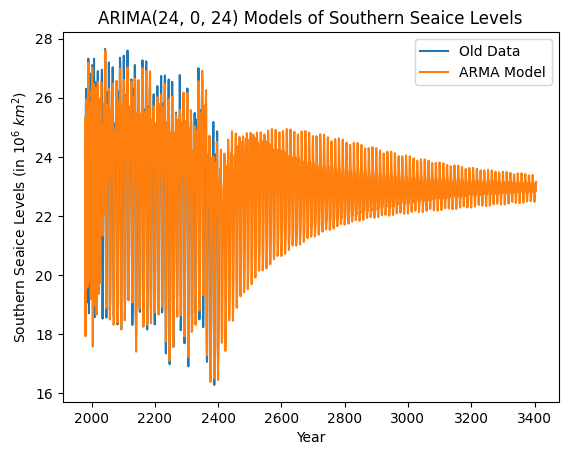

In [12]:
# Fitting an ARMA model to the Southern Seaice dataset
z = seaice_global_df.reset_index(drop=True).groupby(lambda i: i // 31).mean().values.copy()  # The dataset
n = 1000  # The number of predictions to make into the future

# with warnings.catch_warnings():
#     warnings.simplefilter("ignore", ConvergenceWarning)
#     warnings.simplefilter("ignore", UserWarning)
#     # Determining optimal hyperparameters
#     p_max, q_max, d_max = 12, 12, 0
#     opt_p, opt_q, opt_d = None, None, None
#     best_aic = float("inf")
#     for p in range(1, p_max + 1):
#         for q in range(1, q_max + 1):
#             for d in range(0, d_max + 1):
#                 # model = ARIMA(z, order=(p, d, q)).fit(method='innovations_mle')
#                 model = ARIMA(z, order=(p, d, q)).fit(method='statespace')
#                 if model.aic < best_aic:
#                     best_aic = model.aic
#                     opt_p = p
#                     opt_q = q
#                     opt_d = d

# Determining the optimal AIC
print(f"Best AIC: {best_aic}")

opt_p, opt_d, opt_q = 24, 0, 24

# Intialize the ARIMA model with optimal parameters
model = ARIMA(z, order=(opt_p, opt_d, opt_q)).fit(method='statespace')

# Predict from the beginning of the model to n observations in the future
pred = model.predict(start=0, end=len(z)+n)
plt.plot(np.arange(1979 + 1, 1979 + len(z)), z[1:], label="Old Data")
plt.plot(np.arange(1979 + 1, 1979 + len(pred)), pred[1:], label="ARMA Model")
plt.xlabel("Year")
plt.ylabel(r"Southern Seaice Levels (in $10^6 \; km^2$)")
plt.title(f"ARIMA({opt_p}, {opt_d}, {opt_q}) Models of Southern Seaice Levels")
plt.legend()
plt.show()

# Working With Smoothed Data

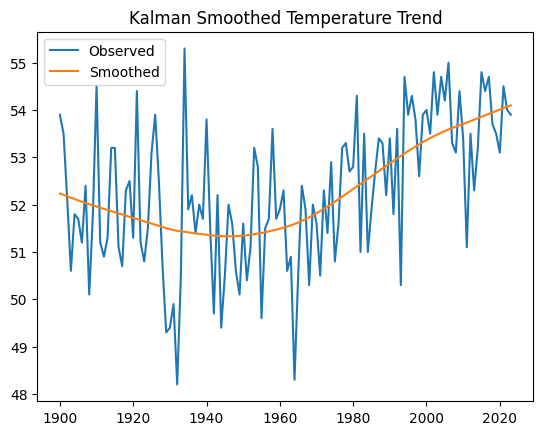

In [13]:
# Code from Japheth's Kalman filter notebook
y = avtemp_df['temp'].copy()
model = UnobservedComponents(y, level='local level')
result = model.fit()

smoothed = result.smoothed_state[0]
filtered = result.filtered_state[0]
forecast = result.get_forecast(steps=10)

y = avtemp_df['temp'].copy()
model = UnobservedComponents(y, level='local linear trend')
result = model.fit()

smoothed_level = result.smoothed_state[0]
smoothed_slope = result.smoothed_state[1]
forecast = result.get_forecast(steps=10)

# Plotting the smoothed data
plt.plot(y.index, y.values, label='Observed')
plt.plot(y.index, smoothed_level, label='Smoothed')
plt.legend()
plt.title('Kalman Smoothed Temperature Trend')
plt.show()

Best AIC: -1319.8438919713951


/Users/ethanpalenske/Desktop/Winter 2026 Classes/.acme/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


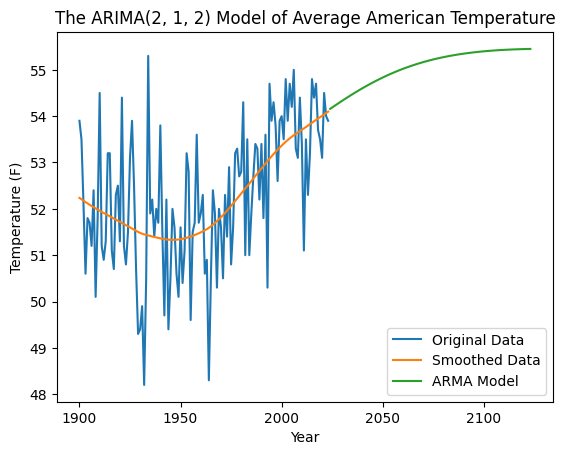

In [ ]:
# Training ARIMA on the smoothed average temperature dataset
y = avtemp_df['temp'].copy()  # The dataset
z = smoothed_level
n = 100  # The number of predictions to make into the future

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    warnings.simplefilter("ignore", UserWarning)
    # Determining optimal hyperparameters
    p_max, q_max, d_max = 4, 4, 3
    opt_p, opt_q, opt_d = None, None, None
    best_aic = float("inf")
    for p in range(1, p_max + 1):
        for q in range(1, q_max + 1):
            for d in range(0, d_max + 1):
                # model = ARIMA(z, order=(p, d, q)).fit(method='innovations_mle')
                model = ARIMA(z, order=(p, d, q)).fit(method='statespace')
                if model.aic < best_aic:
                    best_aic = model.aic
                    opt_p = p
                    opt_q = q
                    opt_d = d

# Determining the optimal AIC
print(f"Best AIC: {best_aic}")

/Users/ethanpalenske/Desktop/Winter 2026 Classes/.acme/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


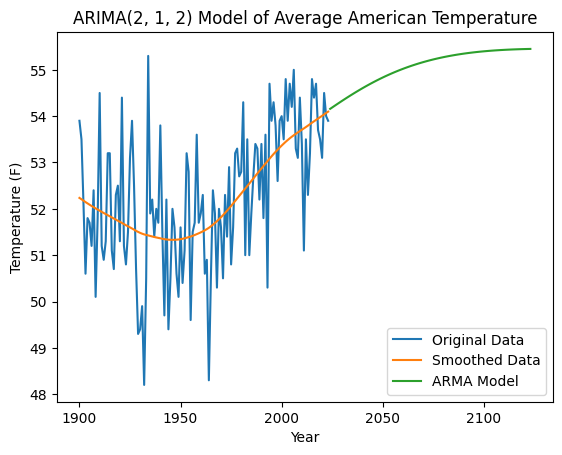

In [36]:

# Intialize the ARIMA model with optimal parameters
model = ARIMA(z, order=(opt_p, opt_d, opt_q)).fit(method='statespace')

# Predict from the beginning of the model to n observations in the future
pred = model.predict(start=len(z), end=len(z) + n)
pred_index = pd.RangeIndex(y.index[-1], y.index[-1] + n + 1, 1)
plt.plot(y.index, y, label="Original Data")
plt.plot(y.index, z, label="Smoothed Data")
plt.plot(pred_index[1:], pred[1:], label="ARMA Model")
plt.xlabel("Year")
plt.ylabel(r"Temperature (F)")
plt.title(f"ARIMA({opt_p}, {opt_d}, {opt_q}) Model of Average American Temperature")
# plt.axvline(2000, c="red", label="Your birth")
# plt.axvline(2035, c="red", label="Your first child's birth")
# plt.axvline(2070, c="red", label="Your first grandchild's birth")
# plt.axvline(2100, c="black", label="You all die")
plt.legend()
plt.show()

## Working on SARIMAX Models

In [15]:
# Combining dataframes before performing SARIMAX
merged_df = pd.merge(avtemp_df['temp'], co2_world_df, left_index=True, right_index=True)
seaice_global_yearly_df["seaice_mean"] = seaice_global_yearly_df["mean"]
seaice_global_yearly_df["seaice_std"] = seaice_global_yearly_df["std"]
merged_df = pd.merge(merged_df, seaice_global_yearly_df[["seaice_mean"]], left_index=True, right_index=True)
# merged_df

In [19]:
# Using cross validation to determine the best SARIMAX hyperparameters
p_vals = list(range(3))
d_vals = list(range(3))
q_vals = list(range(3))
P_vals = list(range(3))
D_vals = list(range(3))
Q_vals = list(range(3))
s_vals = list(range(2, 4))

opt_params = {
    "p": None,
    "d": None,
    "q": None,
    "P": None,
    "D": None,
    "Q": None,
    "s": None,
}

# Running cross validation
best_rmse = float("inf")
for p, d, q, P, D, Q, s in list(product(p_vals, d_vals, q_vals, P_vals, D_vals, Q_vals, s_vals)):
    try:
        # Training the SARIMAX model
        model = SARIMAX(
            avtemp_df["temp"].iloc[:int(0.8*len(avtemp_df))],
            order = (p, d, q),
            seasonal_order= (P, D, Q, s)
        )
        res = model.fit()
        forecast = res.forecast(steps=25)
        score = (np.mean((forecast.values - avtemp_df["temp"].iloc[int(0.8*len(avtemp_df)):])**2))**0.5

        if score < best_rmse:
            best_rmse = score
            opt_params["p"] = p
            opt_params["d"] = d
            opt_params["q"] = q
            opt_params["P"] = P
            opt_params["D"] = D
            opt_params["Q"] = Q
            opt_params["s"] = s
    except:
        continue

print(opt_params)

/Users/ethanpalenske/Desktop/Winter 2026 Classes/.acme/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/Users/ethanpalenske/Desktop/Winter 2026 Classes/.acme/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/Users/ethanpalenske/Desktop/Winter 2026 Classes/.acme/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/Users/ethanpalenske/Desktop/Winter 2026 Classes/.acme/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertibl

{'p': 2, 'd': 0, 'q': 2, 'P': 0, 'D': 1, 'Q': 0, 's': 3}


/Users/ethanpalenske/Desktop/Winter 2026 Classes/.acme/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Optimal found parameters: {'p': 2, 'd': 0, 'q': 2, 'P': 0, 'D': 1, 'Q': 0, 's': 3}

/Users/ethanpalenske/Desktop/Winter 2026 Classes/.acme/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


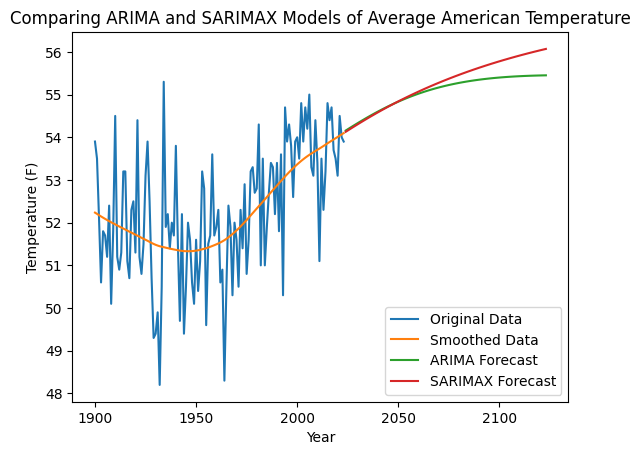

In [41]:
# Building the model
steps = 100
data = smoothed_level.copy()

model = SARIMAX(
            data,
            order = (2, 0, 2),
            seasonal_order= (0, 1, 0, 3)
        )
res = model.fit()
forecast = res.forecast(steps=steps)

# Plotting the results
plt.plot(pd.RangeIndex(1900, 2024), avtemp_df, label="Original Data")
plt.plot(pd.RangeIndex(1900, 2024), data, label="Smoothed Data")
plt.plot(pred_index[1:], pred[1:], label="ARIMA Forecast")
plt.plot(pd.RangeIndex(2024, 2024 + steps), forecast, label="SARIMAX Forecast")
plt.xlabel("Year")
plt.ylabel(r"Temperature (F)")
plt.title(f"Comparing ARIMA and SARIMAX Models of Average American Temperature")
# plt.axvline(2000, c="red", label="Your birth")
# plt.axvline(2035, c="red", label="Your first child's birth")
# plt.axvline(2070, c="red", label="Your first grandchild's birth")
# plt.axvline(2100, c="black", label="You all die")
plt.legend()
plt.show()

## VARIMAX Models

In [17]:
# Using cross validation to determine the best SARIMAX hyperparameters
p_vals = list(range(3))
d_vals = list(range(3))
q_vals = list(range(3))
P_vals = list(range(3))
D_vals = list(range(3))
Q_vals = list(range(3))
s_vals = list(range(12))

opt_params = {
    "p": None,
    "d": None,
    "q": None,
    "P": None,
    "D": None,
    "Q": None,
    "s": None,
}

# Running cross validation
best_rmse = float("inf")
for p, d, q, P, D, Q, s in list(product(p_vals, d_vals, q_vals, P_vals, D_vals, Q_vals, s_vals)):
    # Training the SARIMAX model
    model = SARIMAX(
        merged_df.iloc[:int(0.8*len(merged_df))],
        order = (p, d, q),
        seasonal_order= (P, D, Q, s)
    )
    res = model.fit()
    forecast = model.forecast(steps=int(0.2*len(merged_df)))
    score = (np.mean(forecast.values - merged_df.iloc[int(0.8*len(merged_df)):]))**0.5

    if score < best_rmse:
        best_rmse = score
        opt_params["p"] = p
        opt_params["d"] = d
        opt_params["q"] = q
        opt_params["P"] = P
        opt_params["D"] = D
        opt_params["Q"] = Q
        opt_params["s"] = s

print(opt_params)

ValueError: SARIMAX models require univariate `endog`. Got shape (32, 3).